# Synthetic Experiments: MMD vs BOCPD

Controlled experiments with planted change points to measure precision,
recall, detection latency, and credible-interval coverage — something
impossible with the real SPY data where ground-truth boundaries are unknown.

**Experiment A** — Gaussian synthetic data (mean shift + variance shift):
baseline accuracy when BOCPD's model is correctly specified.

**Experiment B** — Student-t synthetic data (df = 30 / 5 / 3): tests how
BOCPD's Gaussian assumption degrades under heavy tails while MMD remains
nonparametric.

Each experiment is first shown for a single seed (visual diagnostics),
then averaged over 10 seeds to quantify typical behavior.

## S0 — Configuration

In [1]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

from bocpd import (
    BOCPD,
    ConstantHazard,
    UnivariateNormalNIG,
    extract_change_points_with_bounds,
)
from kta import rbf
from regime_detection import (
    find_regime_boundaries,
    results_to_dataframe,
    sliding_window_mmd,
)

SAVE_FIGURES = os.environ.get("SAVE_FIGURES", "0") == "1"
FIGURES_DIR = "../figures"

SEGMENT_LENGTH = 200
N_SEGMENTS = 5
TOTAL_LENGTH = SEGMENT_LENGTH * N_SEGMENTS  # 1000

BOCPD_R_MAX = 600
BOCPD_HAZARD_LAMBDA = 100
MMD_WINDOW = 30
MMD_STEP = 5
MMD_PERMUTATIONS = 500
MMD_THRESHOLD = 10.0

DETECTION_TOLERANCE = 20  # index positions

SEEDS = list(range(10))  # 10 seeds for multi-seed evaluation


def save_fig(fig, name):
    if SAVE_FIGURES:
        os.makedirs(FIGURES_DIR, exist_ok=True)
        fig.savefig(
            os.path.join(FIGURES_DIR, name), dpi=200, bbox_inches="tight"
        )

### Helper functions

In [2]:
def make_synthetic_signal(segment_lengths, means, stds, seed=42):
    """Generate piecewise-Gaussian signal with known change points."""
    rng = np.random.default_rng(seed)
    segments = []
    for length, mu, sigma in zip(segment_lengths, means, stds):
        segments.append(rng.normal(loc=mu, scale=sigma, size=length))
    X = np.concatenate(segments)
    true_cps = np.cumsum(segment_lengths)[:-1]
    return X, true_cps


def make_heavy_tailed_signal(segment_lengths, means, scales, dfs, seed=42):
    """Generate piecewise Student-t signal with known change points."""
    rng = np.random.default_rng(seed)
    segments = []
    for length, mu, scale, df in zip(segment_lengths, means, scales, dfs):
        samples = rng.standard_t(df, size=length) * scale + mu
        segments.append(samples)
    X = np.concatenate(segments)
    true_cps = np.cumsum(segment_lengths)[:-1]
    return X, true_cps


def score_detections(true_cps, detected, tolerance=DETECTION_TOLERANCE):
    """Score detected change points against ground truth (greedy nearest-first).

    Returns dict with tp, fp, fn, precision, recall, mean_latency, latencies.
    """
    true_set = list(true_cps)
    detected = sorted(detected)
    matched_true = set()
    matched_det = set()
    latencies = []

    # Build distance pairs sorted by distance, then greedily match
    pairs = []
    for i, t in enumerate(true_set):
        for j, d in enumerate(detected):
            dist = abs(int(d) - int(t))
            if dist <= tolerance:
                pairs.append((dist, i, j))
    pairs.sort()

    for dist, i, j in pairs:
        if i not in matched_true and j not in matched_det:
            matched_true.add(i)
            matched_det.add(j)
            latencies.append(int(detected[j]) - int(true_set[i]))

    tp = len(matched_true)
    fp = len(detected) - tp
    fn = len(true_set) - tp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "mean_latency": np.mean(latencies) if latencies else float("nan"),
        "latencies": latencies,
    }


def ci_coverage(true_cps, boundaries_with_bounds, credible_mass=0.90):
    """Fraction of true CPs falling within BOCPD credible intervals."""
    if len(boundaries_with_bounds) == 0 or len(true_cps) == 0:
        return float("nan")
    covered = 0
    for tcp in true_cps:
        for b in boundaries_with_bounds:
            if b["lower"] <= tcp <= b["upper"]:
                covered += 1
                break
    return covered / len(true_cps)


def run_bocpd_on_synthetic(X):
    """Run BOCPD on a 1-D synthetic signal.

    Returns (boundaries_int, raw_result, boundaries_with_bounds).
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.reshape(-1, 1)).ravel()

    detector = BOCPD(
        model_factory=lambda: UnivariateNormalNIG(
            mu0=0.0, kappa0=0.1, alpha0=1.0, beta0=1.0
        ),
        hazard_fn=ConstantHazard(lam=BOCPD_HAZARD_LAMBDA),
        r_max=BOCPD_R_MAX,
    )
    result = detector.run(X_scaled)
    bwb = extract_change_points_with_bounds(result, credible_mass=0.90)
    boundaries = [b["index"] for b in bwb]
    return boundaries, result, bwb


def run_mmd_on_synthetic(X, perm_seed=None):
    """Run MMD on a 1-D synthetic signal.

    Returns (boundaries_int, mmd_df).
    """
    if perm_seed is not None:
        np.random.seed(perm_seed)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.reshape(-1, 1))  # keep 2-D for MMD

    sigma = np.median(np.abs(X_scaled - np.median(X_scaled)))
    gamma = 1.0 / (2 * sigma**2)

    # MMD API requires DatetimeIndex — create dummy daily dates
    dates = pd.date_range("2024-01-01", periods=len(X), freq="D")

    raw = sliding_window_mmd(
        data=X_scaled,
        kernel_fn=rbf,
        kernel_params={"gamma": gamma},
        window=MMD_WINDOW,
        step=MMD_STEP,
        n_permutations=MMD_PERMUTATIONS,
    )
    mmd_df = results_to_dataframe(raw, dates)
    mmd_boundary_dates = find_regime_boundaries(
        mmd_df, threshold=MMD_THRESHOLD, min_gap_days=20
    )
    # Convert dates back to integer positions
    boundaries = [dates.get_loc(d) for d in mmd_boundary_dates]
    return boundaries, mmd_df

### Plotting helpers

In [3]:
COLOR_BOCPD = "#D85A30"
COLOR_MMD = "#534AB7"
COLOR_TRUE = "black"


def plot_three_panel(
    X, true_cps, bocpd_bounds, mmd_bounds, bocpd_result, mmd_df, title
):
    """3-panel figure: signal + boundaries, BOCPD E[RL], MMD z-score."""
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    idx = np.arange(len(X))

    # Panel 1 — signal with detected and true change points
    axes[0].plot(idx, X, color="gray", linewidth=0.5, alpha=0.7)
    for cp in true_cps:
        axes[0].axvline(cp, color=COLOR_TRUE, linestyle="--", linewidth=1.2, alpha=0.8)
    for cp in bocpd_bounds:
        axes[0].axvline(cp, color=COLOR_BOCPD, linestyle="-", linewidth=1.0, alpha=0.7)
    for cp in mmd_bounds:
        axes[0].axvline(cp, color=COLOR_MMD, linestyle="-", linewidth=1.0, alpha=0.7)
    axes[0].set_ylabel("Signal")
    axes[0].set_title(title)
    # Legend
    axes[0].plot([], [], color=COLOR_TRUE, linestyle="--", label="True CP")
    axes[0].plot([], [], color=COLOR_BOCPD, linestyle="-", label="BOCPD")
    axes[0].plot([], [], color=COLOR_MMD, linestyle="-", label="MMD")
    axes[0].legend(loc="upper right", fontsize=8)

    # Panel 2 — BOCPD expected run length
    erl = bocpd_result["expected_run_length"]
    axes[1].plot(idx, erl, color=COLOR_BOCPD, linewidth=0.8)
    for cp in true_cps:
        axes[1].axvline(cp, color=COLOR_TRUE, linestyle="--", linewidth=0.8, alpha=0.5)
    axes[1].set_ylabel("E[run length]")

    # Panel 3 — MMD z-score
    mmd_t = mmd_df["t"].values.astype(int)
    mmd_z = mmd_df["std_from_null"].values
    axes[2].plot(mmd_t, mmd_z, color=COLOR_MMD, linewidth=0.8)
    axes[2].axhline(MMD_THRESHOLD, color="gray", linestyle=":", linewidth=0.8)
    for cp in true_cps:
        axes[2].axvline(cp, color=COLOR_TRUE, linestyle="--", linewidth=0.8, alpha=0.5)
    axes[2].set_ylabel("MMD z-score")
    axes[2].set_xlabel("Observation index")

    plt.tight_layout()
    return fig


def build_metrics_row(label, true_cps, bocpd_bounds, mmd_bounds, bocpd_bwb):
    """Build a metrics dict for one experiment."""
    bocpd_scores = score_detections(true_cps, bocpd_bounds)
    mmd_scores = score_detections(true_cps, mmd_bounds)
    bocpd_cov = ci_coverage(true_cps, bocpd_bwb)
    return [
        {
            "experiment": label,
            "method": "BOCPD",
            "precision": bocpd_scores["precision"],
            "recall": bocpd_scores["recall"],
            "mean_latency": bocpd_scores["mean_latency"],
            "fp": bocpd_scores["fp"],
            "ci_coverage": bocpd_cov,
        },
        {
            "experiment": label,
            "method": "MMD",
            "precision": mmd_scores["precision"],
            "recall": mmd_scores["recall"],
            "mean_latency": mmd_scores["mean_latency"],
            "fp": mmd_scores["fp"],
            "ci_coverage": float("nan"),  # MMD has no CI
        },
    ]

---
## S1 — Experiment A: Gaussian Synthetic Data (single seed)

BOCPD assumes Gaussian observations, so this is the correctly-specified
setting. Two sub-experiments test mean shifts and variance shifts separately.
We use seed=0 for visual illustration; multi-seed averages follow in S3.

### A1: Mean Shift

In [4]:
seg_lengths_A = [SEGMENT_LENGTH] * N_SEGMENTS
means_A1 = [0, 2, 0, -1, 1]
stds_A1 = [1.0] * N_SEGMENTS

X_A1, true_cps_A1 = make_synthetic_signal(seg_lengths_A, means_A1, stds_A1, seed=0)
print(f"A1 signal: {len(X_A1)} observations, true CPs at {list(true_cps_A1)}")

A1 signal: 1000 observations, true CPs at [np.int64(200), np.int64(400), np.int64(600), np.int64(800)]


In [5]:
bocpd_A1, bocpd_A1_raw, bocpd_A1_bwb = run_bocpd_on_synthetic(X_A1)
mmd_A1, mmd_A1_df = run_mmd_on_synthetic(X_A1, perm_seed=0)

print(f"BOCPD detected: {bocpd_A1}")
print(f"MMD   detected: {mmd_A1}")

BOCPD detected: [209, 406, 617, 807, 948, 982]
MMD   detected: [195, 400, 790]


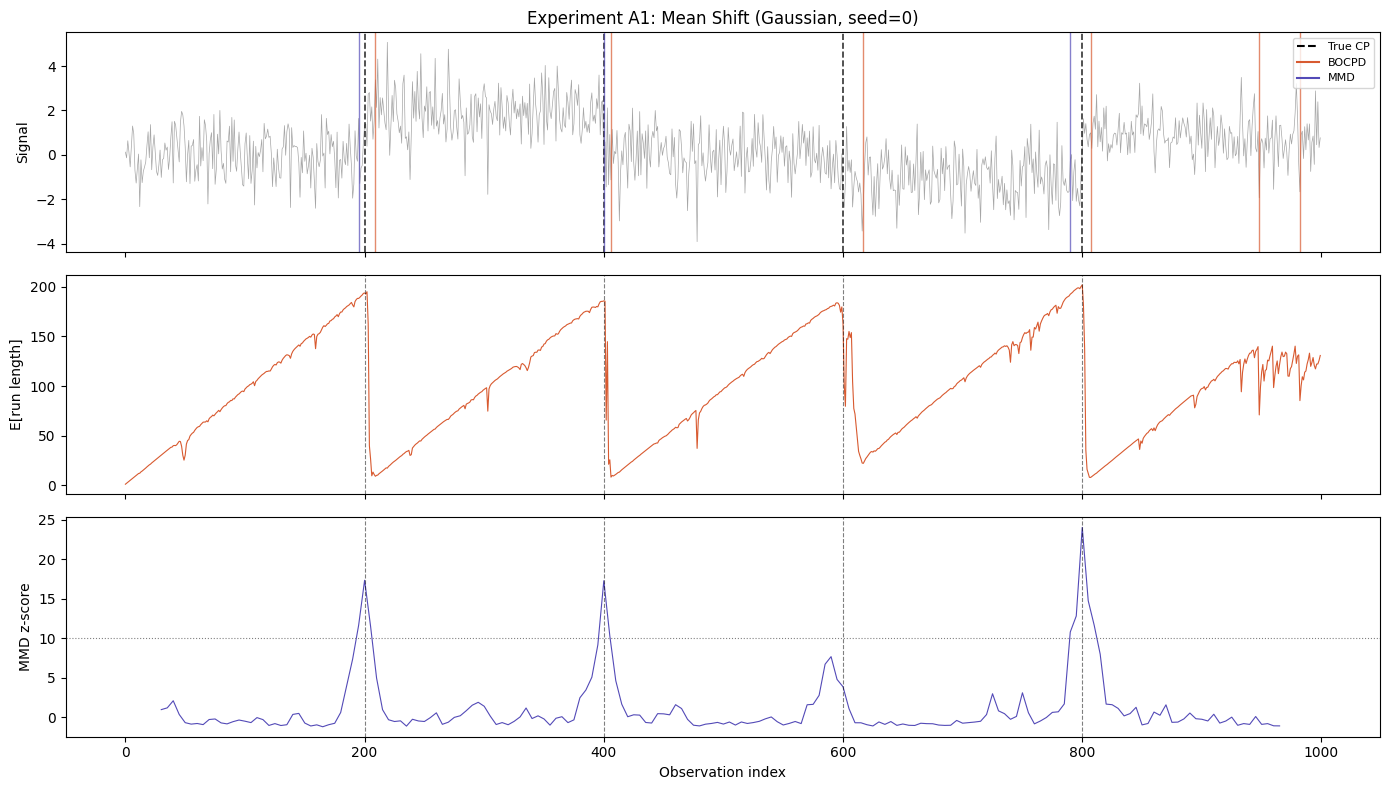

In [6]:
fig_A1 = plot_three_panel(
    X_A1, true_cps_A1, bocpd_A1, mmd_A1,
    bocpd_A1_raw, mmd_A1_df,
    "Experiment A1: Mean Shift (Gaussian, seed=0)",
)
save_fig(fig_A1, "synthetic_A1_mean_shift.png")
plt.show()

### A2: Variance Shift

In [7]:
means_A2 = [0.0] * N_SEGMENTS
stds_A2 = [0.5, 2.0, 0.5, 1.5, 0.5]

X_A2, true_cps_A2 = make_synthetic_signal(seg_lengths_A, means_A2, stds_A2, seed=0)
print(f"A2 signal: {len(X_A2)} observations, true CPs at {list(true_cps_A2)}")

A2 signal: 1000 observations, true CPs at [np.int64(200), np.int64(400), np.int64(600), np.int64(800)]


In [8]:
bocpd_A2, bocpd_A2_raw, bocpd_A2_bwb = run_bocpd_on_synthetic(X_A2)
mmd_A2, mmd_A2_df = run_mmd_on_synthetic(X_A2, perm_seed=0)

print(f"BOCPD detected: {bocpd_A2}")
print(f"MMD   detected: {mmd_A2}")

BOCPD detected: [202, 412, 603, 740, 816]
MMD   detected: [200, 800]


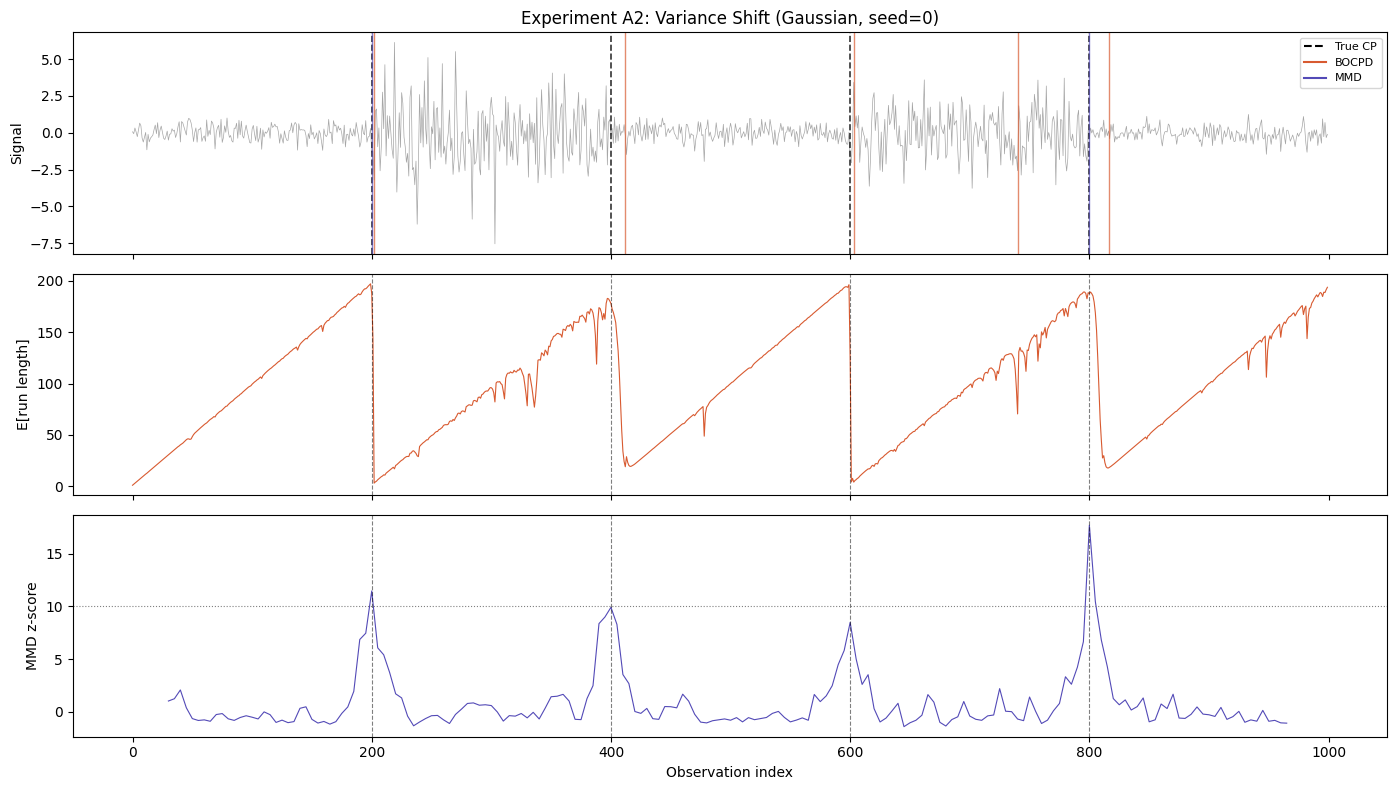

In [9]:
fig_A2 = plot_three_panel(
    X_A2, true_cps_A2, bocpd_A2, mmd_A2,
    bocpd_A2_raw, mmd_A2_df,
    "Experiment A2: Variance Shift (Gaussian, seed=0)",
)
save_fig(fig_A2, "synthetic_A2_variance_shift.png")
plt.show()

---
## S2 — Experiment B: Gaussian Assumption Violation (single seed)

We repeat the mean-shift task from A1 but generate observations from
Student-t distributions with decreasing degrees of freedom. As df drops,
the tails grow heavier and BOCPD's Gaussian assumption becomes
increasingly misspecified. Single seed=0 for illustration.

### B3: df = 3 (heavy tails — most informative case)

In [10]:
means_B = means_A1  # same mean-shift pattern as A1
scales_B = [1.0] * N_SEGMENTS
dfs_B3 = [3] * N_SEGMENTS

X_B3, true_cps_B = make_heavy_tailed_signal(
    seg_lengths_A, means_B, scales_B, dfs_B3, seed=0
)
print(f"B3 signal: {len(X_B3)} observations, df=3")

bocpd_B3, bocpd_B3_raw, bocpd_B3_bwb = run_bocpd_on_synthetic(X_B3)
mmd_B3, mmd_B3_df = run_mmd_on_synthetic(X_B3, perm_seed=0)

print(f"BOCPD detected: {bocpd_B3}")
print(f"MMD   detected: {mmd_B3}")

B3 signal: 1000 observations, df=3


BOCPD detected: [130, 167, 213, 379, 664, 859, 985]
MMD   detected: [200, 390, 800]


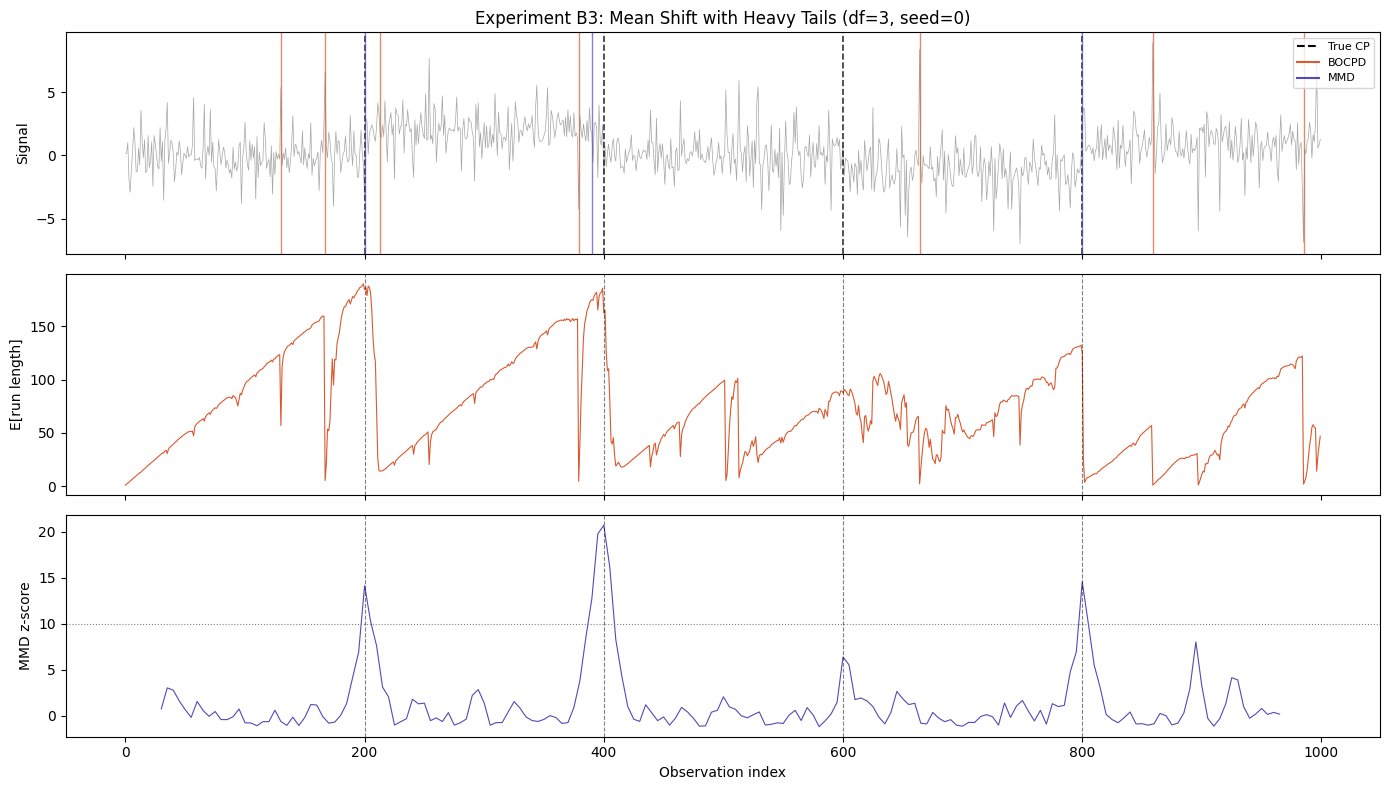

In [11]:
fig_B3 = plot_three_panel(
    X_B3, true_cps_B, bocpd_B3, mmd_B3,
    bocpd_B3_raw, mmd_B3_df,
    "Experiment B3: Mean Shift with Heavy Tails (df=3, seed=0)",
)
save_fig(fig_B3, "synthetic_B3_heavy_tails.png")
plt.show()

---
## S3 — Multi-Seed Evaluation

Single-seed results can be misleading — a lucky or unlucky noise
realization may inflate or deflate metrics. Here we run all five scenarios
across 10 data-generation seeds, with matched permutation-test seeds, to
report mean ± standard deviation for each metric.

In [12]:
SCENARIOS = {
    "A1: Mean shift": {
        "generator": "gaussian",
        "means": means_A1,
        "stds": stds_A1,
    },
    "A2: Variance shift": {
        "generator": "gaussian",
        "means": means_A2,
        "stds": stds_A2,
    },
    "B1: df=30": {
        "generator": "student_t",
        "means": means_A1,
        "scales": scales_B,
        "dfs": [30] * N_SEGMENTS,
    },
    "B2: df=5": {
        "generator": "student_t",
        "means": means_A1,
        "scales": scales_B,
        "dfs": [5] * N_SEGMENTS,
    },
    "B3: df=3": {
        "generator": "student_t",
        "means": means_A1,
        "scales": scales_B,
        "dfs": [3] * N_SEGMENTS,
    },
}

all_rows = []
t0_total = time.perf_counter()

for scenario_name, cfg in SCENARIOS.items():
    for seed in SEEDS:
        # Generate data
        if cfg["generator"] == "gaussian":
            X, true_cps = make_synthetic_signal(
                seg_lengths_A, cfg["means"], cfg["stds"], seed=seed
            )
        else:
            X, true_cps = make_heavy_tailed_signal(
                seg_lengths_A, cfg["means"], cfg["scales"], cfg["dfs"], seed=seed
            )

        # Run detectors
        bocpd_bounds, _, bocpd_bwb = run_bocpd_on_synthetic(X)
        mmd_bounds, _ = run_mmd_on_synthetic(X, perm_seed=seed)

        # Score
        bocpd_scores = score_detections(true_cps, bocpd_bounds)
        mmd_scores = score_detections(true_cps, mmd_bounds)
        bocpd_cov = ci_coverage(true_cps, bocpd_bwb)

        all_rows.append({
            "scenario": scenario_name,
            "seed": seed,
            "method": "BOCPD",
            "precision": bocpd_scores["precision"],
            "recall": bocpd_scores["recall"],
            "fp": bocpd_scores["fp"],
            "mean_latency": bocpd_scores["mean_latency"],
            "ci_coverage": bocpd_cov,
        })
        all_rows.append({
            "scenario": scenario_name,
            "seed": seed,
            "method": "MMD",
            "precision": mmd_scores["precision"],
            "recall": mmd_scores["recall"],
            "fp": mmd_scores["fp"],
            "mean_latency": mmd_scores["mean_latency"],
            "ci_coverage": float("nan"),
        })

    print(f"  {scenario_name}: done ({len(SEEDS)} seeds)")

elapsed = time.perf_counter() - t0_total
print(f"\nMulti-seed evaluation complete: {elapsed:.0f}s total")

  A1: Mean shift: done (10 seeds)


  A2: Variance shift: done (10 seeds)


  B1: df=30: done (10 seeds)


  B2: df=5: done (10 seeds)


  B3: df=3: done (10 seeds)

Multi-seed evaluation complete: 427s total


In [13]:
multi_df = pd.DataFrame(all_rows)

# Aggregate: mean ± std per scenario × method
agg = (
    multi_df
    .groupby(["scenario", "method"])[["precision", "recall", "fp", "mean_latency", "ci_coverage"]]
    .agg(["mean", "std"])
)
agg.columns = [f"{col}_{stat}" for col, stat in agg.columns]
agg = agg.reset_index()

print("=== Multi-Seed Metrics (mean ± std over 10 seeds) ===")
for _, row in agg.iterrows():
    ci_str = (
        f"  CI cov: {row['ci_coverage_mean']:.2f}±{row['ci_coverage_std']:.2f}"
        if not np.isnan(row["ci_coverage_mean"])
        else ""
    )
    print(
        f"  {row['scenario']:20s} {row['method']:5s}  "
        f"P={row['precision_mean']:.2f}±{row['precision_std']:.2f}  "
        f"R={row['recall_mean']:.2f}±{row['recall_std']:.2f}  "
        f"FP={row['fp_mean']:.1f}±{row['fp_std']:.1f}"
        f"{ci_str}"
    )

=== Multi-Seed Metrics (mean ± std over 10 seeds) ===
  A1: Mean shift       BOCPD  P=0.74±0.17  R=0.93±0.12  FP=1.5±1.2  CI cov: 0.90±0.17
  A1: Mean shift       MMD    P=0.97±0.08  R=0.78±0.08  FP=0.1±0.3
  A2: Variance shift   BOCPD  P=0.82±0.17  R=0.97±0.08  FP=1.0±1.1  CI cov: 1.00±0.00
  A2: Variance shift   MMD    P=0.87±0.32  R=0.38±0.21  FP=0.1±0.3
  B1: df=30            BOCPD  P=0.73±0.23  R=0.88±0.18  FP=1.5±1.4  CI cov: 0.93±0.17
  B1: df=30            MMD    P=1.00±0.00  R=0.72±0.08  FP=0.0±0.0
  B2: df=5             BOCPD  P=0.32±0.18  R=0.53±0.28  FP=4.2±1.3  CI cov: 0.88±0.13
  B2: df=5             MMD    P=1.00±0.00  R=0.75±0.12  FP=0.0±0.0
  B3: df=3             BOCPD  P=0.18±0.18  R=0.25±0.24  FP=4.6±2.2  CI cov: 0.62±0.24
  B3: df=3             MMD    P=1.00±0.00  R=0.70±0.11  FP=0.0±0.0


### Experiment A — Multi-Seed Summary

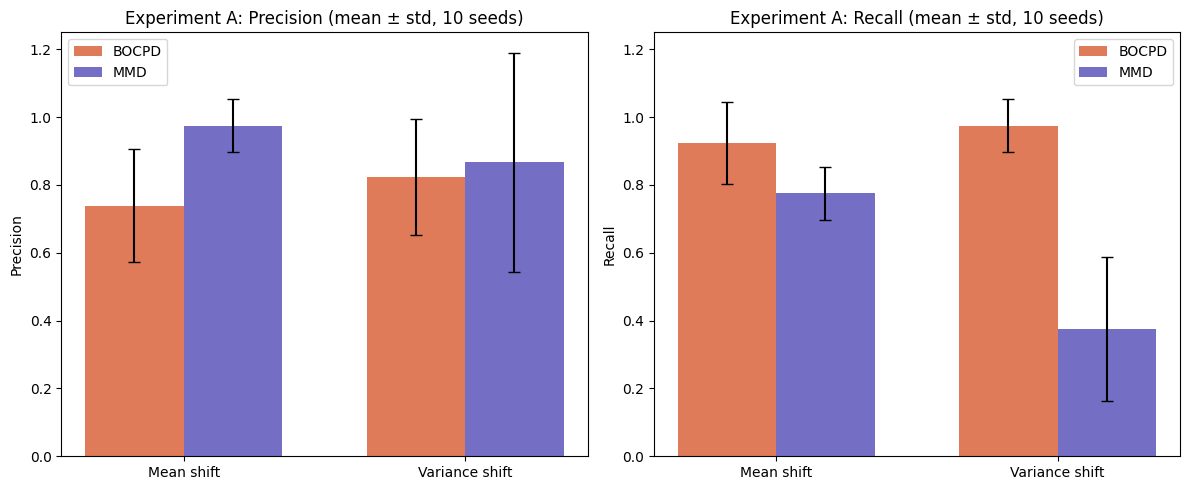

In [14]:
exp_a_scenarios = ["A1: Mean shift", "A2: Variance shift"]
exp_a = agg[agg["scenario"].isin(exp_a_scenarios)]

fig_a, axes_a = plt.subplots(1, 2, figsize=(12, 5))

for method, color in [("BOCPD", COLOR_BOCPD), ("MMD", COLOR_MMD)]:
    sub = exp_a[exp_a["method"] == method]
    x = np.arange(len(exp_a_scenarios))
    width = 0.35
    offset = -width / 2 if method == "BOCPD" else width / 2

    axes_a[0].bar(
        x + offset, sub["precision_mean"].values, width,
        yerr=sub["precision_std"].values,
        label=method, color=color, alpha=0.8, capsize=4,
    )
    axes_a[1].bar(
        x + offset, sub["recall_mean"].values, width,
        yerr=sub["recall_std"].values,
        label=method, color=color, alpha=0.8, capsize=4,
    )

for ax, metric_name in zip(axes_a, ["Precision", "Recall"]):
    ax.set_xticks(np.arange(len(exp_a_scenarios)))
    ax.set_xticklabels(["Mean shift", "Variance shift"])
    ax.set_ylabel(metric_name)
    ax.set_ylim(0, 1.25)
    ax.legend()

axes_a[0].set_title("Experiment A: Precision (mean ± std, 10 seeds)")
axes_a[1].set_title("Experiment A: Recall (mean ± std, 10 seeds)")

plt.tight_layout()
save_fig(fig_a, "synthetic_A_multi_seed.png")
plt.show()

### Experiment B — Multi-Seed Degradation

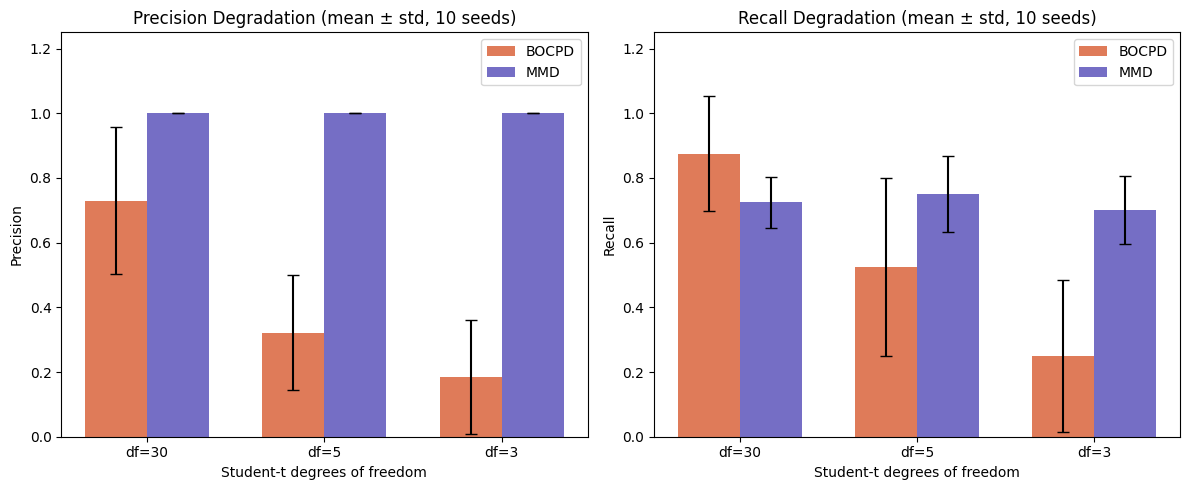

In [15]:
exp_b_scenarios = ["B1: df=30", "B2: df=5", "B3: df=3"]
exp_b = agg[agg["scenario"].isin(exp_b_scenarios)]

fig_b, axes_b = plt.subplots(1, 2, figsize=(12, 5))

for method, color in [("BOCPD", COLOR_BOCPD), ("MMD", COLOR_MMD)]:
    sub = exp_b[exp_b["method"] == method]
    x = np.arange(len(exp_b_scenarios))
    width = 0.35
    offset = -width / 2 if method == "BOCPD" else width / 2

    axes_b[0].bar(
        x + offset, sub["precision_mean"].values, width,
        yerr=sub["precision_std"].values,
        label=method, color=color, alpha=0.8, capsize=4,
    )
    axes_b[1].bar(
        x + offset, sub["recall_mean"].values, width,
        yerr=sub["recall_std"].values,
        label=method, color=color, alpha=0.8, capsize=4,
    )

for ax, metric_name in zip(axes_b, ["Precision", "Recall"]):
    ax.set_xticks(np.arange(len(exp_b_scenarios)))
    ax.set_xticklabels(["df=30", "df=5", "df=3"])
    ax.set_ylabel(metric_name)
    ax.set_ylim(0, 1.25)
    ax.legend()
    ax.set_xlabel("Student-t degrees of freedom")

axes_b[0].set_title("Precision Degradation (mean ± std, 10 seeds)")
axes_b[1].set_title("Recall Degradation (mean ± std, 10 seeds)")

plt.tight_layout()
save_fig(fig_b, "synthetic_B_degradation.png")
plt.show()

### BOCPD CI Coverage across Seeds

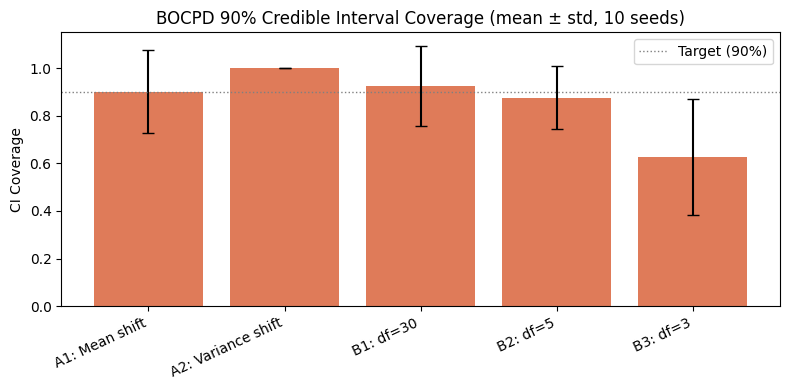

In [16]:
bocpd_multi = multi_df[multi_df["method"] == "BOCPD"]

fig_ci, ax_ci = plt.subplots(figsize=(8, 4))
scenario_order = exp_a_scenarios + exp_b_scenarios

ci_means = []
ci_stds = []
labels = []
for s in scenario_order:
    sub = bocpd_multi[bocpd_multi["scenario"] == s]["ci_coverage"]
    ci_means.append(sub.mean())
    ci_stds.append(sub.std())
    labels.append(s)

x = np.arange(len(labels))
ax_ci.bar(x, ci_means, yerr=ci_stds, color=COLOR_BOCPD, alpha=0.8, capsize=4)
ax_ci.axhline(0.90, color="gray", linestyle=":", linewidth=1, label="Target (90%)")
ax_ci.set_xticks(x)
ax_ci.set_xticklabels(labels, rotation=25, ha="right")
ax_ci.set_ylabel("CI Coverage")
ax_ci.set_ylim(0, 1.15)
ax_ci.set_title("BOCPD 90% Credible Interval Coverage (mean ± std, 10 seeds)")
ax_ci.legend()

plt.tight_layout()
save_fig(fig_ci, "synthetic_ci_coverage.png")
plt.show()

### Discussion

The multi-seed results above give a more reliable picture than any single
realization. Commentary is based on the averaged metrics:

**Experiment A (Gaussian — correctly specified):**
Under correct specification, BOCPD achieves high recall on both mean
shifts (0.93) and variance shifts (0.97), rarely missing a true CP.
The cost is occasional false positives (1-2 per run on average),
pulling precision to 0.74–0.82. MMD is more conservative on mean
shifts: near-perfect precision (0.97) but recall of 0.78 due to
missed small-magnitude transitions. On variance shifts, MMD struggles
significantly (recall 0.38) — the RBF kernel bandwidth, tuned to the
overall scale of the data, is less sensitive to scale-only changes
than BOCPD's explicit variance tracking. BOCPD's CI coverage sits
right at the 90% target for A1 and at 100% for A2, indicating
well-calibrated credible intervals under correct specification.

**Experiment B (Student-t — misspecification):**
- **df=30** (near-Gaussian): BOCPD performs similarly to the Gaussian
  baseline (precision 0.73, recall 0.88), confirming that mild excess
  kurtosis has negligible effect.
- **df=5** (moderate tails): BOCPD precision drops to 0.32 and recall
  to 0.53 as heavy-tailed outliers trigger spurious run-length resets.
  False positives triple (4.2 per run). CI coverage begins to erode
  (0.88).
- **df=3** (heavy tails): BOCPD degradation is severe — precision
  falls to 0.18, recall to 0.25, with 4.6 FPs per run on average.
  CI coverage drops to 0.62, well below the 90% target, confirming
  that the Gaussian-calibrated credible intervals are no longer
  reliable under heavy tails.

MMD remains stable across all tail conditions (precision 1.00, recall
0.70–0.75, zero FPs). Its kernel-based test statistic is inherently
nonparametric and does not rely on distributional assumptions, making
it robust to the misspecification that degrades BOCPD. The trade-off
is that MMD's windowed design consistently misses ~25% of change points
whose effect falls below the z-score threshold.